# Regression in Python
## Notebook 1: Terminology, Definitions, and Simple Linear Regression

### Learning goals

By the end of this notebook, you should be able to:

- explain what a regression model is,
- define independent variable / feature and dependent variable / target variable,
- explain the meaning of $x$, $y$, and $\hat{y}$,
- fit a simple linear regression model using `sklearn`,
- interpret the intercept and slope,
- compute and interpret residuals,
- explain the difference between $r$ and $R^2$,
- explain why extrapolation can be risky.

## 1. What is a regression model?

A **regression model** is used to predict a **numeric output** from one or more input variables.

We write this idea formally as:

$$
\hat{y} = f(x)
$$

where:

- $x$ represents the **input variable(s)**,
- $y$ represents the **observed output variable**,
- $\hat{y}$ represents the **predicted value** of $y$.

The key requirement in regression is that the output variable must be **numeric**.

Examples of numeric outputs:

- exam score,
- house price,
- weekly sales,
- body weight.

## 2. Key terminology

### Independent variable / feature: $x$

The **independent variable** is the input we use to make a prediction.

It is also often called:

- a **feature**,
- a **predictor**,
- an **explanatory variable**.

Examples:

- hours studied,
- house size,
- advertising budget.

If there is one input variable, we write it as $x$. If there are multiple, we write $x_1, x_2, x_3, \dots$

### Dependent variable / target variable: $y$

The **dependent variable** is the output we want to predict.

It is also often called:

- the **target variable**,
- the **response variable**.

Examples:

- exam score,
- house price,
- sales amount.

In regression, $y$ must be numeric.

### Predicted value: $\hat{y}$

$\hat{y}$ (read: "y-hat") is the **predicted value** of the dependent variable produced by the model.

For example:

- if $x$ is **hours studied**,
- and $y$ is **exam score**,

then $\hat{y}$ is the **predicted exam score** for a given number of study hours.

### Residual

The **residual** of one observation is:

$$
\text{residual} = y - \hat{y}
$$

That is:

- $y$ = the observed (actual) value,
- $\hat{y}$ = the predicted value.

The residual tells us how far the prediction is from the actual value.

- A **positive residual** means the model underestimated — the actual value was higher than predicted.
- A **negative residual** means the model overestimated — the actual value was lower than predicted.

A good regression model should have residuals that are small on average.

### Extrapolation

A regression model can be used to predict values that were not observed in the original data.

However, predictions are only reliable when the new value of $x$ is **within or near the original data range**.

An **extrapolation** is a prediction made far outside the observed data range. Extrapolations are often unreliable or misleading, because there is no evidence that the same relationship holds outside the observed range.

In [ ]:
# Import the packages we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression #use LinearRegression method available in sklearn.linear_model package.

## 3. Simple linear regression

A **simple linear regression** model uses **one independent variable** to predict **one numeric dependent variable**.

The model has the form:

$$
\hat{y} = b_0 + b_1 x
$$

where:

- $b_0$ is the **intercept**: the predicted value of $y$ when $x = 0$,
- $b_1$ is the **slope**: how much $\hat{y}$ changes when $x$ increases by 1 unit.

The model finds the values of $b_0$ and $b_1$ that best fit the data, using a method called **least squares** (described in Section 6).

## 4. Example: Hours Studied vs. Exam Score

In this example:

- the **independent variable / feature** is `HoursStudied`,
- the **dependent variable / target variable** is `ExamScore`.

We will use hours studied to predict exam score.

---

You may load the data in **one of two ways**:

- **Option 1 (Code cell 2-1):** create the DataFrame directly from a Python dictionary — no file needed.
- **Option 2 (Code cell 2-2):** read from a CSV file — place `exam_score.csv` in the same folder as this notebook.

Both options create the same DataFrame named `study_df`.  
Running **both** cells is **harmless**. If the CSV file is missing, Option 2 will display a message and your notebook can still continue using Option 1.


In [ ]:
# Code cell 2-1
# Option 1: Create the dataset directly from a Python dictionary

study_dict = {
    "HoursStudied": [1, 2, 2, 3, 4, 4, 5, 6, 6, 7, 8, 9, 10],
    "ExamScore":    [52, 55, 57, 60, 63, 65, 68, 72, 74, 78, 82, 88, 91]
}
study_df = pd.DataFrame(study_dict) # study_dict --> coverted to --> dataframe, stduy_df

study_df

,HoursStudied,ExamScore
0,1,52
1,2,55
2,2,57
3,3,60
4,4,63
5,4,65
6,5,68
7,6,72
8,6,74
9,7,78


In [ ]:

# Option 2: Read the dataset from a CSV file
# Make sure exam_score.csv is in the same folder as this notebook

# mount google drive
from google.colab import drive
drive.mount("/content/drive")


# you need to change the path below.
study_df = pd.read_csv("exam_score.csv")


MessageError: Error: credential propagation was unsuccessful

## 5. Exploring the data

Before fitting a model, it is always good practice to look at the data visually.

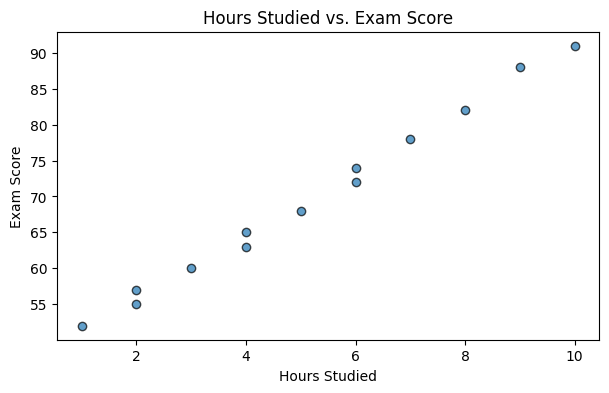

In [ ]:
# Create a scatter plot of HoursStudied vs ExamScore
plt.figure(figsize=(7, 4))
plt.scatter(
    study_df["HoursStudied"],
    study_df["ExamScore"],
    alpha=0.7,
    edgecolors="k"
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs. Exam Score")
plt.show()

The scatter plot shows a **positive linear relationship**: as study hours increase, exam score tends to increase in a roughly straight-line pattern.

This makes simple linear regression a reasonable first choice.

## 6. Preparing $X$ and $y$ for sklearn

Before fitting the model, we need to separate the data into:

- `X` — the **independent variable(s)** / feature(s),
- `y` — the **dependent variable** / target.

In `sklearn`, `X` must be a **2D structure** (a DataFrame or a 2D array) and `y` must be a **1D structure** (a Series or a 1D array).

A clean way to do this with pandas:

- use **double brackets** `[[...]]` for `X` to keep it as a DataFrame (2D),
- use **single brackets** `[...]` for `y` to get a Series (1D).

In [ ]:
X = study_df['HoursStudied']
X

,HoursStudied
0,1
1,2
2,2
3,3
4,4
5,4
6,5
7,6
8,6
9,7


In [ ]:
X = study_df[['HoursStudied']]   # --> this is the one we should use for X
X

,HoursStudied
0,1
1,2
2,2
3,3
4,4
5,4
6,5
7,6
8,6
9,7


### Step 1 --> Prepare X and y

In [ ]:
# X contains the feature (independent variable) — double brackets keep it 2D
X = study_df[["HoursStudied"]]

# y contains the target (dependent variable) — single brackets give a 1D Series
y = study_df["ExamScore"]

print("Shape of X:", X.shape)   # should be (n_rows, 1)
print("Shape of y:", y.shape)   # should be (n_rows,)

print("\nFirst few rows of X:")
print(X.head())

print("\nFirst few values of y:")
print(y.head())

Shape of X: (13, 1)
Shape of y: (13,)

First few rows of X:
   HoursStudied
0             1
1             2
2             2
3             3
4             4

First few values of y:
0    52
1    55
2    57
3    60
4    63
Name: ExamScore, dtype: int64


## 7. Fitting the simple linear regression model

We now create the model object and fit it to the data.

Fitting the model means finding the values of $b_0$ and $b_1$ that minimize the prediction errors.

### Step 2 --> create model object using LinearRegression()




*   from sklearn.linear_model import LinearRegression




In [ ]:
simple_model = LinearRegression() #simple_model is my model object


### Step 3: Fit the model to the data using fit(X, y)  -Fit means training!

In [ ]:
# Step 3: Fit the model to the data
# Fit ---> Training
simple_model.fit(X, y)

LinearRegression()

### Step 4 --> Extract the intercept and slope!

In [ ]:
# Step 4: Extract the intercept and slope
b0 = simple_model.intercept_
b1 = simple_model.coef_[0]

print(f"Intercept (b0): {b0:.4f}")
print(f"Slope     (b1): {b1:.4f}")
print()
print(f"Fitted equation: ŷ = {b0:.4f} + {b1:.4f} × (HoursStudied)")


Intercept (b0): 46.7918
Slope     (b1): 4.4285

Fitted equation: ŷ = 46.7918 + 4.4285 × (HoursStudied)


## 8. The least squares method

How does `sklearn` choose the best values of $b_0$ and $b_1$?

It uses the **least squares method**, which finds the line that minimizes the **sum of squared residuals (SSE)**:

$$
SSE = \sum (y - \hat{y})^2
$$

In other words, the best regression line is the one that makes the squared prediction errors as small as possible overall.

Squaring the residuals ensures that:

- large errors are penalized more heavily than small errors,
- positive and negative errors do not cancel each other out.

## 9. Interpreting the regression equation

The fitted equation printed above has the form:

$$
\hat{y} = b_0 + b_1 \times (\text{HoursStudied})
$$

The cell below uses the actual values of `b0` and `b1` from the fitted model to print the interpretation automatically. This way the interpretation will always match the output above, even if the data change.

In [ ]:
# Print a plain-language interpretation of the fitted coefficients
print("Interpretation of the regression equation")
print("-" * 45)
print(f"Slope (b1) = {b1:.4f}")
print(f"  → For every additional 1 hour studied, the predicted")
print(f"    exam score increases by {b1:.2f} points.")
print()
print(f"Intercept (b0) = {b0:.4f}")
print(f"  → When hours studied = 0, the predicted exam score is {b0:.2f}.")
print(f"    In this example, the intercept has a reasonable")
print(f"    interpretation as a baseline score.")
print()
print("Note: the intercept is not always practically meaningful.")
print("If x = 0 is outside the observed data range, the intercept")
print("still anchors the line but may not represent a realistic case.")

Interpretation of the regression equation
---------------------------------------------
Slope (b1) = 4.4285
  → For every additional 1 hour studied, the predicted
    exam score increases by 4.43 points.

Intercept (b0) = 46.7918
  → When hours studied = 0, the predicted exam score is 46.79.
    In this example, the intercept has a reasonable
    interpretation as a baseline score.

Note: the intercept is not always practically meaningful.
If x = 0 is outside the observed data range, the intercept
still anchors the line but may not represent a realistic case.


## 10. Predicting specific values of $\hat{y}$

Once the regression model has been fitted, we can use `simple_model.predict()` to find a **predicted value**.

In this notebook:

- $x$ = `HoursStudied`
- $y$ = observed exam score
- $\hat{y}$ = **predicted exam score**

So in this section, we are **not** looking for $y$.  
We are looking for:


$\hat{y}$


that is, the model's **predicted** exam score.

### Example 1: Predict one value of $\hat{y}$

Suppose:

\[
x = 3
\]

That means a student studied for 3 hours.

We want to find:

$
\hat{y}
$

the predicted exam score.

In [ ]:
# Time to predict: Fit -----> Predict

y_hat = simple_model.predict([[3]])  #
#Note that predict method needs a 2D as an input--> you should use [[3]], not [3]

print("Predicted exam score (y_hat) when HoursStudied = 3:")

y_hat  # your score --> 60.07 when x = 3

Predicted exam score (y_hat) when HoursStudied = 3:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([60.07717042])

Here:

- `[[3]]` means **1 row, 1 feature**
- the output is $\hat{y}$, the **predicted exam score**

So this answers the question:

**“If a student studies for 3 hours, what exam score does the model predict?”**

### Example 2: Predict several values of $\hat{y}$

Now suppose we want predictions for several values of $x$:

- $x = 3$
- $x = 5$
- $x = 8$

Then the model will return three predicted values of $\hat{y}$.


In [ ]:
# Short form: predict several values of y_hat


y_hat_multi = simple_model.predict([[3], [5], [8]])  # predict!!!!
#note that you canNOT use this [3,5, 8]
# you cannot use: [[3, 5, 8]]  -> no no
#You should use [[3], [5], [8]]

print("Predicted exam scores (y_hat values):")
y_hat_multi
# x = 3--> 60 points, x =5, 68.93 points, x=8 --> 82.21

Predicted exam scores (y_hat values):


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([60.07717042, 68.9340836 , 82.21945338])

Here:

- `[[3], [5], [8]]` means:
  - first row: $x=3$
  - second row: $x=5$
  - third row: $x=8$

So the model returns three predicted values of $\hat{y}$.

### Important note

For this notebook, the model has only **one feature**: `HoursStudied`.

So this is correct:

```python
[[3], [5], [8]]
```

But this is **not** correct for this model:

```python
[[3, 5, 8]]
```

because that would mean:

- 1 row
- 3 features

and our simple regression model uses only **one feature**.

### A more complete version: use a DataFrame

The short forms `[[3]]` and `[[3], [5], [8]]` are fine for quick predictions.

However, in practice, it is often better to use a **DataFrame** because:

- it is easier to read,
- it matches the training data format,
- the column name makes it clear which feature is being used.

In [ ]:
# A more complete and readable version using a DataFrame
new_hours = pd.DataFrame({
    "HoursStudied": [3, 5, 8]
}) #new_hours is not a dataframe!!!!

y_hat_df = simple_model.predict(new_hours)
#new_hours (dataframe) is provided to an input to method predict

prediction_df = new_hours.copy()
prediction_df["PredictedScore"] = y_hat_df

prediction_df

,HoursStudied,PredictedScore
0,3,60.077170
1,5,68.934084
2,8,82.219453


In this table:

- `HoursStudied` is the input $x$
- `PredictedScore` is the predicted value $\hat{y}$

So this version shows clearly that the model takes in values of $x$ and returns predicted values of $\hat{y}$.

### Summary of this section

- If you want **one prediction**, you may use:

```python
simple_model.predict([[3]])
```

- If you want **several predictions**, you may use:

```python
simple_model.predict([[3], [5], [8]])
```

- If you want a more complete and readable version, use a **DataFrame**.

In all cases, the output is $\hat{y}$, the **predicted exam score**, not the observed score $y$.


## 11. Visualizing the regression line

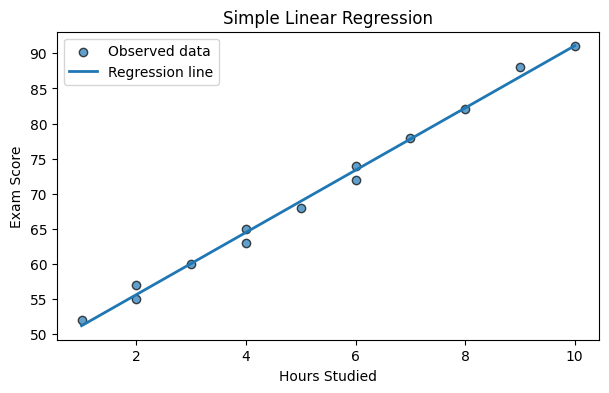

In [ ]:
# Compute predicted values and store them in the DataFrame
study_df["PredictedScore"] = simple_model.predict(X)

# Sort by HoursStudied so the line is drawn cleanly
study_df_sorted = study_df.sort_values("HoursStudied")

# Plot observed data and the regression line
plt.figure(figsize=(7, 4))
plt.scatter(
    study_df["HoursStudied"],
    study_df["ExamScore"],
    alpha=0.7,
    edgecolors="k",
    label="Observed data"
)
plt.plot(
    study_df_sorted["HoursStudied"],
    study_df_sorted["PredictedScore"],
    linewidth=2,
    label="Regression line"
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

The regression line shows the predicted exam score for each number of study hours.

- Points **above** the line have **positive residuals** (model underestimated).
- Points **below** the line have **negative residuals** (model overestimated).

## 12. Computing and visualizing residuals

In [ ]:
# Compute residuals: observed - predicted
study_df["Residual"] = study_df["ExamScore"] - study_df["PredictedScore"]

# Display all columns
study_df

,HoursStudied,ExamScore,PredictedScore,Residual
0,1,52,51.220257,0.779743
1,2,55,55.648714,-0.648714
2,2,57,55.648714,1.351286
3,3,60,60.077170,-0.077170
4,4,63,64.505627,-1.505627
5,4,65,64.505627,0.494373
6,5,68,68.934084,-0.934084
7,6,72,73.362540,-1.362540
8,6,74,73.362540,0.637460
9,7,78,77.790997,0.209003


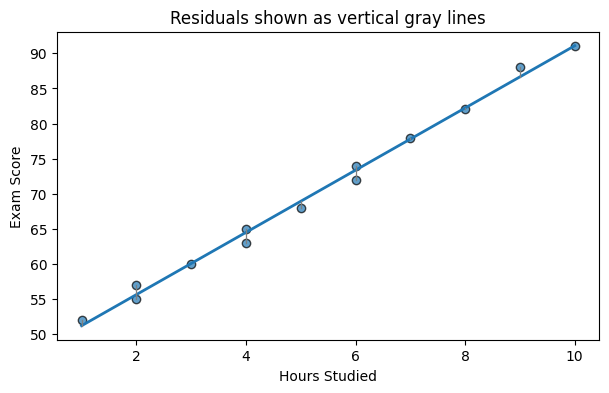

In [ ]:
# Visualize residuals as vertical gray lines from each point to the regression line
plt.figure(figsize=(7, 4))
plt.scatter(
    study_df["HoursStudied"],
    study_df["ExamScore"],
    alpha=0.7,
    edgecolors="k"
)
plt.plot(
    study_df_sorted["HoursStudied"],
    study_df_sorted["PredictedScore"],
    linewidth=2
)

# Draw one residual line for each observation
for _, row in study_df.iterrows():
    plt.plot(
        [row["HoursStudied"], row["HoursStudied"]],
        [row["ExamScore"],    row["PredictedScore"]],
        color="gray",
        linewidth=0.9
    )

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Residuals shown as vertical gray lines")
plt.show()

Each gray vertical line represents the residual $y - \hat{y}$ for one observation.

- **Short lines** → small prediction errors (the model fits well at that point).
- **Long lines** → larger prediction errors.

The least squares method minimizes the **sum of the squared residuals**.

## 13. Understanding $R^2$ and $r$

In simple linear regression, two important quantities are:

- $R^2$: the **coefficient of determination**
- $r$: the **correlation coefficient**

They are related, but they do **not** mean the same thing.

In this section, we will study them one at a time.


### 13.1 Coefficient of determination: $R^2$

$R^2$ tells us how much of the variation in the dependent variable $y$ is explained by the regression model.

Its range is:

$$
0 \le R^2 \le 1
$$

Interpretation:

- $R^2 = 0$: the model explains none of the variation in $y$
- $R^2 = 1$: the model explains all of the variation in $y$

For example:

- if $R^2 = 0.80$, then about 80% of the variation in exam score is explained by hours studied
- the remaining 20% is due to other factors or random variation


In [ ]:
# Compute R-squared using sklearn
r_squared = simple_model.score(X, y)

print(f"R^2 = {r_squared:.4f}")

R^2 = 0.9945


### Interpreting $R^2$

Now let us interpret the value of $R^2$ in context.

In this example:

- the independent variable is `HoursStudied`
- the dependent variable is `ExamScore`

So $R^2$ tells us how much of the variation in **exam score** is explained by **hours studied**.


In [ ]:
# Interpret R-squared in context
print(f"About {r_squared * 100:.1f}% of the variation in exam score")
print("is explained by HoursStudied.")

print(f"The remaining {(1 - r_squared) * 100:.1f}%")
print("is explained by other factors or random variation.")

### 13.2 Correlation coefficient: $r$

The correlation coefficient $r$ measures the **strength and direction** of the linear relationship between two variables.

Its range is:

$$
-1 \le r \le 1
$$

Interpretation:

- $r = 1$: perfect positive linear relationship
- $r = -1$: perfect negative linear relationship
- $r = 0$: no linear relationship

A positive value means that as $x$ increases, $y$ tends to increase.  
A negative value means that as $x$ increases, $y$ tends to decrease.


In [ ]:
# Compute the correlation coefficient r
r = study_df["HoursStudied"].corr(study_df["ExamScore"])

print(f"r = {r:.4f}")

r = 0.9972


### Interpreting $r$

Now let us interpret $r$.

In this example, $r$ describes the linear relationship between:

- `HoursStudied`
- `ExamScore`

So $r$ tells us whether the relationship is positive or negative, and whether it is weak or strong.


In [ ]:
# Interpret r in context
if r > 0:
    direction = "positive"
elif r < 0:
    direction = "negative"
else:
    direction = "no"

abs_r = abs(r)

if abs_r >= 0.7:
    strength = "strong"
elif abs_r >= 0.3:
    strength = "moderate"
else:
    strength = "weak"

print(f"The relationship between HoursStudied and ExamScore is {strength} and {direction}.")

### 13.3 Summary: $R^2$ versus $r$

Although $R^2$ and $r$ are related, they answer different questions.

- $R^2$ tells us:  
  **How much of the variation in $y$ is explained by the regression model?**

- $r$ tells us:  
  **How strong is the linear relationship, and is it positive or negative?**

So:

- $R^2$ focuses on **explained variation**
- $r$ focuses on **strength and direction**


In [ ]:
# Compare r^2 and R^2
print(f"r^2 = {r**2:.4f}")
print(f"R^2 = {r_squared:.4f}")

In **simple linear regression** only, the following relationship holds:

$$
R^2 = r^2
$$

But remember:

- they are numerically related,
- they do **not** mean the same thing.

So when you interpret them, be careful:

- $R^2$ is about **variation explained**
- $r$ is about **strength and direction of a linear relationship**


### Exercise

1. Interpret the $R^2$ value in one sentence.  
2. Interpret the $r$ value in one sentence.  
3. Does $r^2$ match the $R^2$ value here? Why should they be equal in simple linear regression?


## 14. Prediction and extrapolation

Once the model is fitted, we can use it to predict exam scores for new values of hours studied.

However, predictions are only reliable when the new $x$ value is **within or near the original data range**.

In [ ]:
# Check the observed range of HoursStudied
print("Observed range of HoursStudied:")
print(f"  Min = {study_df['HoursStudied'].min()} hours")
print(f"  Max = {study_df['HoursStudied'].max()} hours")
print()

# Predict for a value inside the observed range and one far outside
new_hours = pd.DataFrame({"HoursStudied": [6, 15]})
predictions = simple_model.predict(new_hours)

prediction_df = new_hours.copy()
prediction_df["PredictedScore"] = predictions
prediction_df["Type"] = ["Interpolation (inside range)", "Extrapolation (outside range)"]

prediction_df

Observed range of HoursStudied:
  Min = 1 hours
  Max = 10 hours



,HoursStudied,PredictedScore,Type
0,6,73.36254,Interpolation (inside range)
1,15,113.21865,Extrapolation (outside range)


- The prediction for **6 hours** is an **interpolation** — it is within the observed range and is more trustworthy.
- The prediction for **15 hours** is an **extrapolation** — it is outside the observed range. Even though the model produces a number, there is no evidence the linear trend holds that far out, and the result may be unreliable.

## 15. Practice questions

1. In this example, what is the independent variable $x$?
2. In this example, what is the dependent variable $y$?
3. What does the slope $b_1$ mean in the context of this example?
4. What does the intercept $b_0$ mean in the context of this example? Is it practically meaningful here?
5. Why is predicting at 15 hours an extrapolation? Why might it be unreliable?
6. What does the $R^2$ value tell us about how well hours studied predicts exam score?
7. What is the difference between $r$ and $R^2$? Can they ever give conflicting information?

## 16. Answer key

Run the cell below to print answers using the **actual fitted model values** from this notebook.

In [ ]:
# Answer key for the practice questions
print("Answers to the practice questions")
print("-" * 42)
print("1. The independent variable x is HoursStudied.")
print("2. The dependent variable y is ExamScore.")
print(f"3. The slope b1 = {b1:.4f}. This means that for each additional 1 hour studied,")
print(f"   the predicted exam score increases by about {b1:.2f} points.")
print(f"4. The intercept b0 = {b0:.4f}. This means that when hours studied = 0,")
print(f"   the predicted exam score is about {b0:.2f}. In this example,")
print("   it can be interpreted as a baseline score.")
print(f"5. Predicting at 15 hours is an extrapolation because 15 is outside the observed")
print(f"   data range of {study_df['HoursStudied'].min()} to {study_df['HoursStudied'].max()} hours.")
print("   It may be unreliable because the linear pattern may not continue that far.")
print(f"6. R² = {r_squared:.4f}, so about {r_squared*100:.1f}% of the variation in exam score")
print("   is explained by hours studied.")
print(f"7. r = {r:.4f} measures the strength and direction of the linear relationship.")
print(f"   R² = {r_squared:.4f} measures the proportion of variation in y explained by the model.")
print("   In simple linear regression, R² = r², so they are consistent,")
print("   but r keeps the sign while R² does not.")

Answers to the practice questions
------------------------------------------
1. The independent variable x is HoursStudied.
2. The dependent variable y is ExamScore.
3. The slope b1 = 4.4285. This means that for each additional 1 hour studied,
   the predicted exam score increases by about 4.43 points.
4. The intercept b0 = 46.7918. This means that when hours studied = 0,
   the predicted exam score is about 46.79. In this example,
   it can be interpreted as a baseline score.
5. Predicting at 15 hours is an extrapolation because 15 is outside the observed
   data range of 1 to 10 hours.
   It may be unreliable because the linear pattern may not continue that far.
6. R² = 0.9945, so about 99.4% of the variation in exam score
   is explained by hours studied.
7. r = 0.9972 measures the strength and direction of the linear relationship.
   R² = 0.9945 measures the proportion of variation in y explained by the model.
   In simple linear regression, R² = r², so they are consistent,
   but 

## 17. Summary

In this notebook, we learned that:

| Term | Meaning |
|---|---|
| $x$ | Independent variable / feature |
| $y$ | Dependent variable / target variable |
| $\hat{y}$ | Predicted value of $y$ |
| Residual | $y - \hat{y}$ (observed minus predicted) |
| $r$ | Correlation coefficient: strength and direction of linear relationship |
| $R^2$ | Proportion of variation in $y$ explained by the model |
| Extrapolation | Prediction far outside the observed data range — use with caution |

### Key formulas

Simple linear regression:
$$\hat{y} = b_0 + b_1 x$$

Residual:
$$\text{residual} = y - \hat{y}$$

Sum of squared errors:
$$SSE = \sum (y - \hat{y})^2$$

Coefficient of determination:
$$R^2 = 1 - \frac{SSE}{SST}$$

In simple linear regression: $R^2 = r^2$

---

**Next:** Notebook 2 will extend these ideas to models with two or more input features — multiple linear regression.